# Ettin classifier (jhu-clsp/ettin-encoder-400m)

The SOTA encoder - [Ettin Suite: SoTA Paired Encoders and Decoders](https://huggingface.co/blog/ettin)

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import json

from google.colab import drive, userdata

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch
from datasets import Dataset

### Set up Google Drive mounting and define input/output paths:

In [2]:
# Mount the google drive folder
drive.mount('/content/drive', force_remount = True) # force reconnection

# Define directory, input, and output paths
project_directory = "/content/drive/MyDrive/Colab Notebooks/DS266/final_project"

# Input file with all original-rewrite pairs
final_file = os.path.join(project_directory, "data/final_long_no_leak.parquet")

# # Output file
# output_file = os.path.join(project_directory, "data/out.parquet")

# Ensure the output directory exists
if not os.path.exists(project_directory):
  os.makedirs(project_directory)

Mounted at /content/drive


### Read the input file:

In [3]:
# Read input file with ALL sampled original-rewrite pairs
final_df = pd.read_parquet(final_file)
print('Sucessfully read the input file with ALL original-rewrite pairs!')

print(f'The input file contains {len(final_df)} records/rows.')
print(f'Column names: {list(final_df.columns)}')

print('\nThe first 3 rows:')
display(final_df.head(3))

Sucessfully read the input file with ALL original-rewrite pairs!
The input file contains 105097 records/rows.
Column names: ['question', 'original_answer', 'rewritten_answer', 'original_author', 'rewrite_author', 'split']

The first 3 rows:


,question,original_answer,rewritten_answer,original_author,rewrite_author,split
0,what composer used sound mass,The most prominent composer strongly associate...,The most prominent composer associated with th...,gemini,claude,train
1,where did the persian war take place,The Persian Wars primarily took place in **mai...,The Persian Wars primarily took place across *...,gemini,claude,train
2,what are add ons,An **add-on** is something extra or additional...,An **add-on** is an optional component that en...,gemini,claude,train


### Data Exploration & cleaning

In [4]:
print(final_df['original_author'].value_counts(), end = '\n\n')
print(final_df['rewrite_author'].value_counts())

original_author
gpt       21160
claude    21138
human     21024
gemini    20980
kimi      20795
Name: count, dtype: int64

rewrite_author
kimi      26477
claude    26456
gemini    26297
gpt       25867
Name: count, dtype: int64


In [5]:
print(final_df.isna().sum(), end = '\n\n')

# na_df -- the dataframe that contains nan responses (rewrites)
na_df = final_df[final_df['rewritten_answer'].isna()]

print(na_df['rewrite_author'].value_counts())
display(na_df.head(3))

question            0
original_answer     0
rewritten_answer    0
original_author     0
rewrite_author      0
split               0
dtype: int64

Series([], Name: count, dtype: int64)


,question,original_answer,rewritten_answer,original_author,rewrite_author,split


Create the binary `labels` column (human `1` vs. machine `0`)

In [6]:
# # drop nan and duplicates
# cleaned_df = final_df.dropna(subset = ['rewritten_answer']).drop_duplicates().reset_index(drop = True)

# print(cleaned_df.isna().sum(), end = '\n\n')
# print(cleaned_df['labels'].value_counts(), end = '\n\n')
# display(cleaned_df.head(3))

# Create the 'labels' column
final_df['labels'] = (final_df['original_author'] == 'human').astype(int)

In [7]:
# train-test split --> DO THIS FIRST BC SPLIT IS PREASSIGNED

# Combine test and val
train_df = final_df[final_df['split'] == 'train'].reset_index(drop = True)
test_df = final_df[final_df['split'].isin(['test', 'val'])].reset_index(drop = True)

print(f'Total samples: {len(final_df)}')
print(f'Training samples: {len(train_df)} | {len(train_df)/len(final_df):.2%}')
print(f'Testing samples: {len(test_df)} | {len(test_df)/len(final_df):.2%}')

Total samples: 105097
Training samples: 73586 | 70.02%
Testing samples: 31511 | 29.98%


In [8]:
# stratification (train)

df_human = train_df[train_df['original_author'] == 'human']
df_gemini = train_df[train_df['original_author'] == 'gemini']
df_gpt = train_df[train_df['original_author'] == 'gpt']
df_claude = train_df[train_df['original_author'] == 'claude']
df_kimi = train_df[train_df['original_author'] == 'kimi']

                                        # number of human responses = 4 * individual llm responses
df_human_sampled = df_human.sample(n = int(len(df_human)/4)*4, random_state = 42)
df_gemini_sampled = df_gemini.sample(n = int(len(df_human)/4), random_state = 42)
df_gpt_sampled = df_gpt.sample(n = int(len(df_human)/4), random_state = 42)
df_claude_sampled = df_claude.sample(n = int(len(df_human)/4), random_state = 42)
df_kimi_sampled = df_kimi.sample(n = int(len(df_human)/4), random_state = 42)

train_df = pd.concat([df_human_sampled, df_gemini_sampled, df_gpt_sampled, df_claude_sampled, df_kimi_sampled]).reset_index(drop = True)
print(train_df['original_author'].value_counts(), end = '\n\n')
print(train_df['labels'].value_counts(), end = '\n\n')
display(train_df.head(3))

original_author
human     14724
gemini     3681
gpt        3681
claude     3681
kimi       3681
Name: count, dtype: int64

labels
1    14724
0    14724
Name: count, dtype: int64



,question,original_answer,rewritten_answer,original_author,rewrite_author,split,labels
0,What market conditions favor small cap stocks ...,"In general, small cap stocks are exposed to mo...",Small-cap stocks typically face greater downsi...,human,claude,train,1
1,Is there an advantage to keeping a liquid emer...,Let me offer what I did in a similar situation...,Allow me to share my experience in a similar s...,human,gemini,train,1
2,If banks offer a fixed rate lower than the var...,Usually that is the case that when fixed rates...,"Typically, when fixed rates are lower than var...",human,gemini,train,1


In [9]:
# stratification (test)

df_human = test_df[test_df['original_author'] == 'human']
df_gemini = test_df[test_df['original_author'] == 'gemini']
df_gpt = test_df[test_df['original_author'] == 'gpt']
df_claude = test_df[test_df['original_author'] == 'claude']
df_kimi = test_df[test_df['original_author'] == 'kimi']

                                        # number of human responses = 4 * individual llm responses
df_human_sampled = df_human.sample(n = int(len(df_human)/4)*4, random_state = 42)
df_gemini_sampled = df_gemini.sample(n = int(len(df_human)/4), random_state = 42)
df_gpt_sampled = df_gpt.sample(n = int(len(df_human)/4), random_state = 42)
df_claude_sampled = df_claude.sample(n = int(len(df_human)/4), random_state = 42)
df_kimi_sampled = df_kimi.sample(n = int(len(df_human)/4), random_state = 42)

test_df = pd.concat([df_human_sampled, df_gemini_sampled, df_gpt_sampled, df_claude_sampled, df_kimi_sampled]).reset_index(drop = True)
print(test_df['original_author'].value_counts(), end = '\n\n')
print(test_df['labels'].value_counts(), end = '\n\n')
display(test_df.head(3))

original_author
human     6296
gemini    1574
gpt       1574
claude    1574
kimi      1574
Name: count, dtype: int64

labels
1    6296
0    6296
Name: count, dtype: int64



,question,original_answer,rewritten_answer,original_author,rewrite_author,split,labels
0,What's the justification for the DJIA being sh...,The share-price weighting of the DJIA is a his...,The share-price weighting of the Dow Jones Ind...,human,gemini,val,1
1,Q. I am experiencing heart flutters and skippe...,Hello. Hope this helps you and get back if you...,I hope this information is helpful. If you hav...,human,kimi,val,1
2,Difference between 'split and redemption' of s...,It is the first time I encounter redemption pr...,This is my first time encountering a redemptio...,human,gpt,val,1


In [10]:
# Shuffle the data (train+val+test individually)
shuffled_indices_train = np.random.permutation(len(train_df))
shuffled_indices_test = np.random.permutation(len(test_df))

train_df = train_df.iloc[shuffled_indices_train].reset_index(drop = True)
test_df = test_df.iloc[shuffled_indices_test].reset_index(drop = True)

print(f'Unique \'split\' values in the training dataset: {train_df["split"].unique()}')
print(f'Unique \'split\' values in the testing dataset: {test_df["split"].unique()}\n')

# Verify that the split was done correctly
display(train_df.head(2))
display(test_df.head(2))

Unique 'split' values in the training dataset: ['train']
Unique 'split' values in the testing dataset: ['val' 'test']



,question,original_answer,rewritten_answer,original_author,rewrite_author,split,labels
0,What causes breathlessness during nights?I am ...,I’m sorry you’re dealing with this — constant ...,I understand you're experiencing constant brea...,gpt,gemini,train,0
1,"What is the lump between the buttocks?Hi, i re...","I understand why you’re frightened, but from y...","I understand why you're frightened, but based ...",kimi,claude,train,0


,question,original_answer,rewritten_answer,original_author,rewrite_author,split,labels
0,"Allocating IRA money, clarification needed",I can help — but “allocating IRA money” could ...,I can help — but “allocating IRA money” can me...,gpt,gpt,val,0
1,Can I get a mortgage from a foreign bank?,You definitely used to be able to (see this BB...,You could historically obtain this (as evidenc...,human,claude,val,1


In [11]:
# Check if there's class imbalance --> roughly balanced
print(f'Label value counts on the training dataset:\n{train_df['labels'].value_counts()}')
print(f'Label value counts on the testing dataset:\n{test_df['labels'].value_counts()}')

Label value counts on the training dataset:
labels
0    14724
1    14724
Name: count, dtype: int64
Label value counts on the testing dataset:
labels
0    6296
1    6296
Name: count, dtype: int64


In [12]:
# Convert the training and testing dataset to Dataset format

train_data = Dataset.from_pandas(train_df[['original_answer', 'rewritten_answer', 'labels']])
test_data = Dataset.from_pandas(test_df[['original_answer', 'rewritten_answer', 'labels']])

### Ettin classifier development

Define tokenizer

In [13]:
ettin_checkpoint = 'jhu-clsp/ettin-encoder-400m'
ettin_tokenizer = AutoTokenizer.from_pretrained(ettin_checkpoint)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

Define the training and testing inputs

In [14]:
def tokenization(df):
  return ettin_tokenizer(df['original_answer'],
                         df['rewritten_answer'],
                         padding = 'max_length',
                         truncation = True,
                         max_length = 512)

train_tokenized = train_data.map(tokenization, batched = True)
train_tokenized.set_format('torch')

test_tokenized = test_data.map(tokenization, batched = True)
test_tokenized.set_format('torch')

Map:   0%|          | 0/29448 [00:00<?, ? examples/s]

Map:   0%|          | 0/12592 [00:00<?, ? examples/s]

Define metrics

In [15]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis = -1)

    return {'accuracy': accuracy_score(labels, predictions),
            'f1_score': f1_score(labels, predictions, average = 'binary')}

### Baseline model (untrained Ettin)

In [16]:
ettin_baseline_model = AutoModelForSequenceClassification.from_pretrained(ettin_checkpoint, num_labels = 2) # binary classification

baseline_training_args = TrainingArguments(output_dir = './ettin_baseline',
                                           per_device_eval_batch_size = 8)

baseline_trainer = Trainer(model = ettin_baseline_model,
                           args = baseline_training_args,
                           eval_dataset = test_tokenized,
                           compute_metrics = compute_metrics)

pytorch_model.bin:   0%|          | 0.00/1.58G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/172 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/ettin-encoder-400m
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
decoder.weight    | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
baseline_results = baseline_trainer.evaluate()

model.safetensors:   0%|          | 0.00/1.58G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:321: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


In [18]:
print(f"(Baseline) Accuracy: {baseline_results['eval_accuracy']} | F1: {baseline_results['eval_f1_score']}")

(Baseline) Accuracy: 0.6836880559085133 | F1: 0.65761196595891


### Fine-tuned model (trained)

In [19]:
ettin_finetuned_model = AutoModelForSequenceClassification.from_pretrained(ettin_checkpoint, num_labels = 2) # binary classification

finetune_training_args = TrainingArguments(output_dir = './ettin_finetuned',
                                           num_train_epochs = 3,              # likely to converge already
                                           learning_rate = 0.00002,
                                           per_device_train_batch_size = 8,   # to prevent overfitting
                                           per_device_eval_batch_size = 8,    # to prevent overfitting
                                           eval_strategy = 'epoch',
                                           save_strategy = 'epoch',
                                           weight_decay = 0.01,               # prevent overfitting to specific punctuation habits
                                           load_best_model_at_end = True,
                                           metric_for_best_model = 'f1_score',
                                           logging_steps = 100,
                                           warmup_steps = 500)                # stablize gradients

finetune_trainer = Trainer(model = ettin_finetuned_model,
                           args = finetune_training_args,
                           train_dataset = train_tokenized,
                           eval_dataset = test_tokenized,
                           compute_metrics = compute_metrics)

finetune_trainer.train()

Loading weights:   0%|          | 0/172 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/ettin-encoder-400m
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
decoder.weight    | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Score
1,0.008324,0.010949,0.997935,0.997937
2,0.000000,0.011017,0.998015,0.998014
3,0.000000,0.011878,0.997776,0.997778


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=11043, training_loss=0.01766198430883312, metrics={'train_runtime': 7482.4592, 'train_samples_per_second': 11.807, 'train_steps_per_second': 1.476, 'total_flos': 9.342872823649075e+16, 'train_loss': 0.01766198430883312, 'epoch': 3.0})

In [20]:
finetuned_results = finetune_trainer.evaluate()

In [21]:
print(f"(Baseline) Accuracy: {baseline_results['eval_accuracy']} | F1: {baseline_results['eval_f1_score']}")
print(f"(Finetuned) Accuracy: {finetuned_results['eval_accuracy']} | F1: {finetuned_results['eval_f1_score']}")

(Baseline) Accuracy: 0.6836880559085133 | F1: 0.65761196595891
(Finetuned) Accuracy: 0.9980146124523507 | F1: 0.9980144547692796


### Visualization

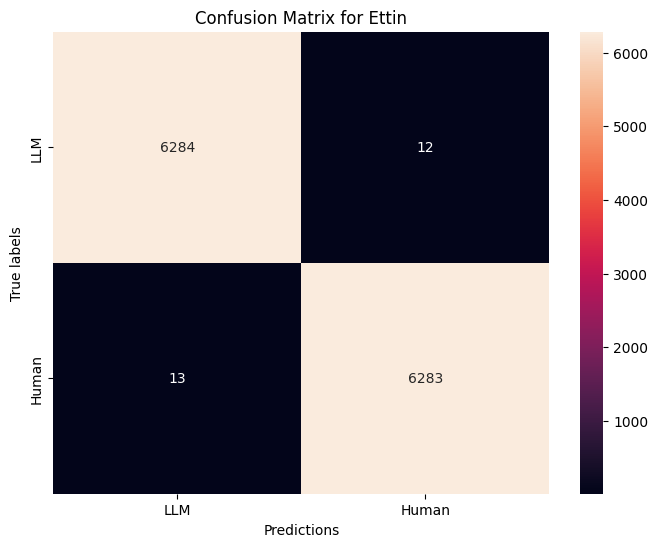


Classification Report:
              precision    recall  f1-score   support

         LLM       1.00      1.00      1.00      6296
       Human       1.00      1.00      1.00      6296

    accuracy                           1.00     12592
   macro avg       1.00      1.00      1.00     12592
weighted avg       1.00      1.00      1.00     12592



In [22]:
predictions = finetune_trainer.predict(test_tokenized)
pred = np.argmax(predictions.predictions, axis = -1)
labels = test_df['labels'].values

cm = confusion_matrix(labels, pred)
plt.figure(figsize = (8,6))
sns.heatmap(cm,
            annot = True,
            fmt = 'd', # format the annotation from scientific to decimals
            xticklabels = ['LLM', 'Human'],
            yticklabels = ['LLM', 'Human'])
plt.xlabel('Predictions')
plt.ylabel('True labels')
plt.title('Confusion Matrix for Ettin')
plt.show()

print("\nClassification Report:")
print(classification_report(labels, pred, target_names = ['LLM', 'Human']))

### Save the final dataframe to parquet

In [23]:
finetune_trainer.save_model("./finetuned_ettin")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]